# Pneumonia Detection using CNNs

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.api.models import Sequential
from keras.api.layers import (
    Dense, 
    Conv2D, 
    MaxPool2D, 
    Flatten, 
    Dropout, 
    BatchNormalization, 
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from keras.api.callbacks import ReduceLROnPlateau

import cv2
import os
from pathlib import Path

In [14]:
labels = ["PNEUMONIA", "NORMAL"]

def get_images(data_dir: Path) -> tuple[np.ndarray, ...]:
    image_size = 150
    image_shape = (image_size, image_size)

    x = []
    y = []
    for class_num, label in enumerate(labels):
        path = data_dir / label
        for file in path.iterdir():
            img_arr = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
            resized_arr = cv2.resize(img_arr, image_shape)
            x.append(resized_arr)
            y.append(class_num)
    return np.array(x), np.array(y)

In [12]:
data_root_dir = Path(".").resolve().parent / "data"

x_train, y_train = get_images(data_root_dir / "train")
print(x_train.shape)

x_valid, y_valid = get_images(data_root_dir / "val")
print(x_valid.shape)

x_test, y_test = get_images(data_root_dir / "test")
print(x_test.shape)

(5216, 150, 150)
(16, 150, 150)
(624, 150, 150)


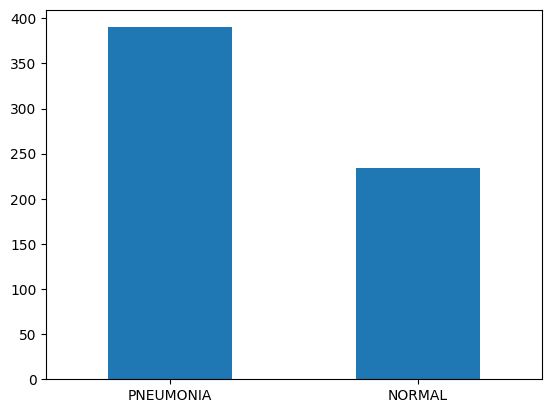

In [36]:
fig, ax = plt.subplots()

train_splits = pd.Series(y_test).value_counts()
train_splits.plot(kind = "bar", ax = ax)
ax.set_xticks(train_splits.index)
ax.set_xticklabels(labels, fontdict={"rotation": 0})
plt.show()

In [47]:
# Normalize the data
x_train = x_train / 255
x_valid = x_valid / 255
x_test = x_test / 255

In [48]:
x_train = x_train.reshape(-1, 150, 150, 1)
x_valid = x_valid.reshape(-1, 150, 150, 1)
x_test = x_test.reshape(-1, 150, 150, 1)